In [1]:
# ====================================================================
# Part B — Predictive modeling, continuing from the same cleaned data
# ====================================================================

In [2]:
%pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\valin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.metrics import auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


In [4]:
df = pd.read_csv("titanic.csv")

# --------------------------------------------------------------
# B.7 Split the data into train/test sets, using a stratified split
# --------------------------------------------------------------

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)
'''
In Task 1, exploratory data analysis of the target variable (survived) revealed an imbalanced class distribution
approximately 38% survived vs. 62% did not survive.
A standard random split carries the risk of unevenly distributing these positive and negative outcomes between the training and testing sets.
By setting stratify=y, train_test_split enforces identical class proportions across both the training(80%) and testing(20%) subsets.
'''

'\nIn Task 1, exploratory data analysis of the target variable (survived) revealed an imbalanced class distribution\napproximately 38% survived vs. 62% did not survive.\nA standard random split carries the risk of unevenly distributing these positive and negative outcomes between the training and testing sets.\nBy setting stratify=y, train_test_split enforces identical class proportions across both the training(80%) and testing(20%) subsets.\n'

In [5]:
# -----------------------------------------
# B.8 Preprocessing (fit on training data only)
# -----------------------------------------
numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(
    steps = [
        ('imputer',SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps = [
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist'))
    ]
)

preprocessor = ColumnTransformer(transformers = [
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
]
)

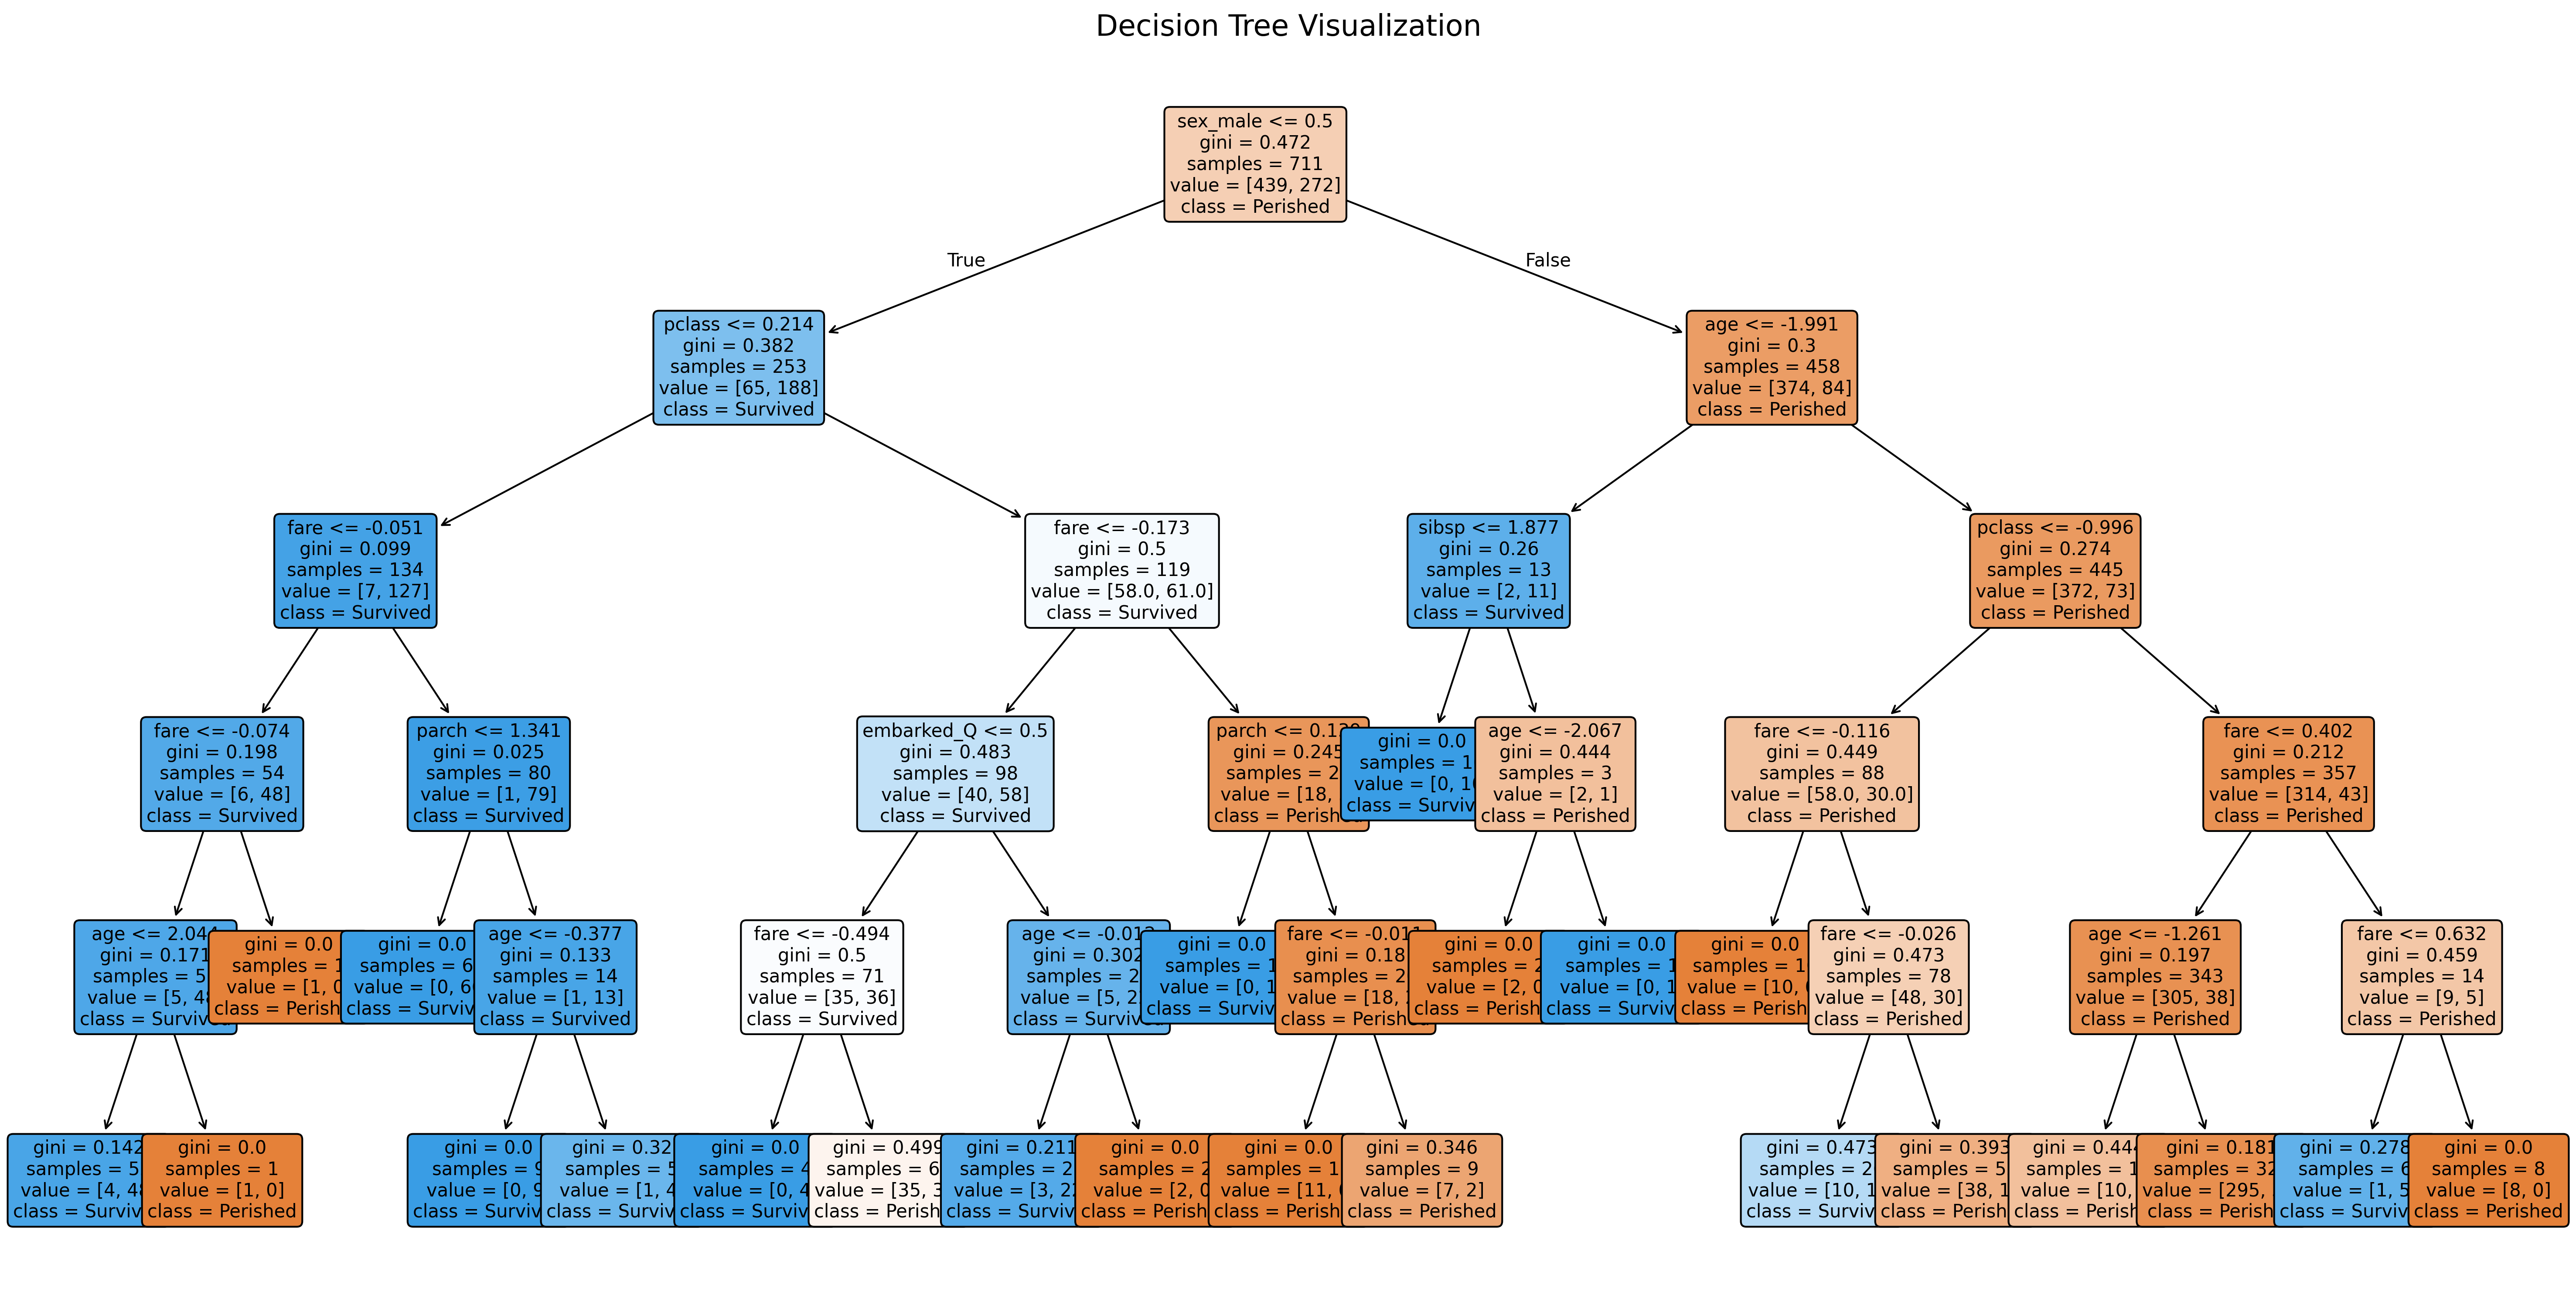

In [6]:
# ----------------------------------------------------------------------------------------------------------
# B.9 Train using Logistic Regression, Decision Tree, Random Forest and render Decision Tree with plot_tree
# ----------------------------------------------------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42,n_jobs=-1),
}

# 2. Iterate through dictionary and train models separately
trained_pipelines = {}
roc_data = {}
metrics_list = []

for name, model in models.items():
    clf_pipeline = Pipeline(
        steps=[("preprocessor", preprocessor), ("model", model)]
    )

    # Train pipeline on X_train, y_train
    clf_pipeline.fit(X_train, y_train)
    trained_pipelines[name] = clf_pipeline

    # Predict on test set
    y_pred = clf_pipeline.predict(X_test)
    y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

    # Calculate ROC metrics
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc_val = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    metrics_list.append(
        {
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1 Score": round(f1, 4),
            "ROC-AUC": round(roc_auc_val, 4),
            "Confusion Matrix (TN, FP, FN, TP)": f"[{cm[0,0]}, {cm[0,1]}, {cm[1,0]}, {cm[1,1]}]",
        }
    )
# Check if Decision Tree exists in your trained pipelines dictionary
if "Decision Tree" in trained_pipelines:
  # 1. Fetch Decision Tree pipeline
  dt_pipeline = trained_pipelines["Decision Tree"]

  # Extract feature names from preprocessor
  raw_features = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()
  clean_features = [f.replace("num__", "").replace("cat__", "") for f in raw_features]

  # Render Tree
  plt.figure(figsize=(20, 10), dpi=300)
  plot_tree(
        dt_pipeline.named_steps["model"],
        feature_names=clean_features,
        class_names=["Perished", "Survived"],
        filled=True,
        rounded=True,
        fontsize=10,
    )
  plt.title("Decision Tree Visualization", fontsize=16, pad=15)
  plt.tight_layout()
  plt.savefig("Decision Tree.png", dpi=300)
  plt.show()


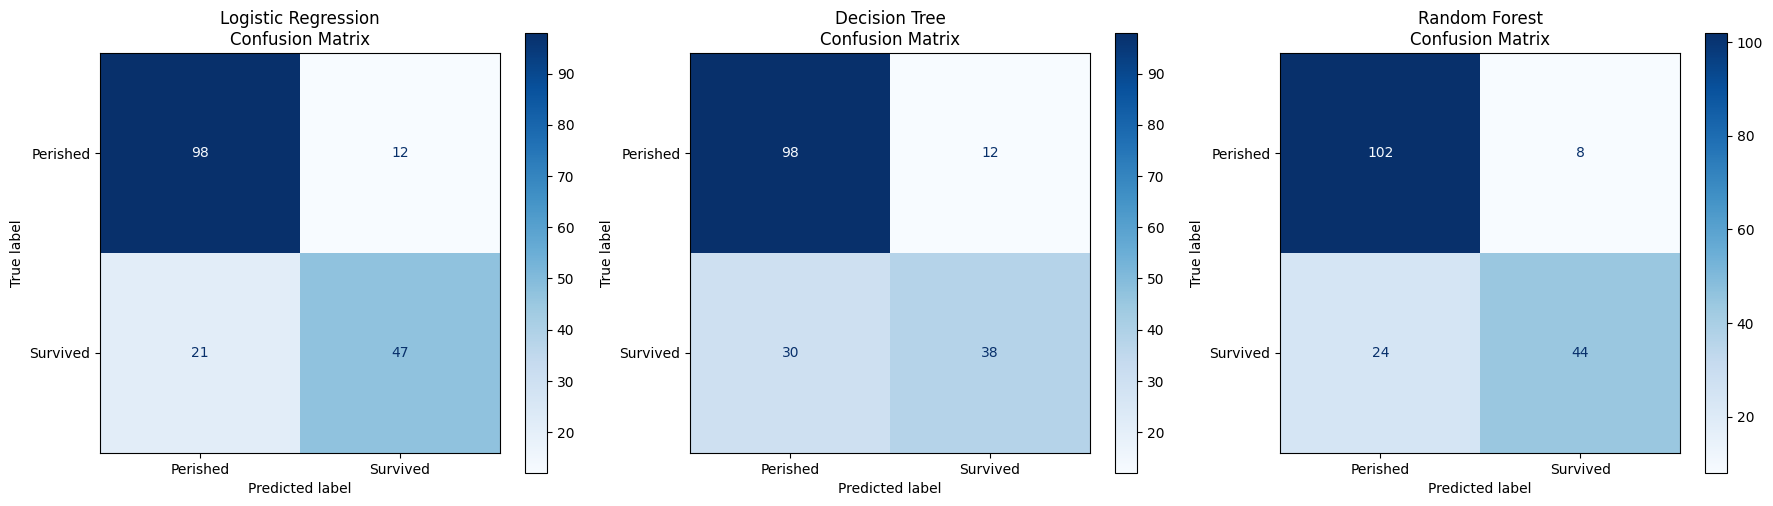

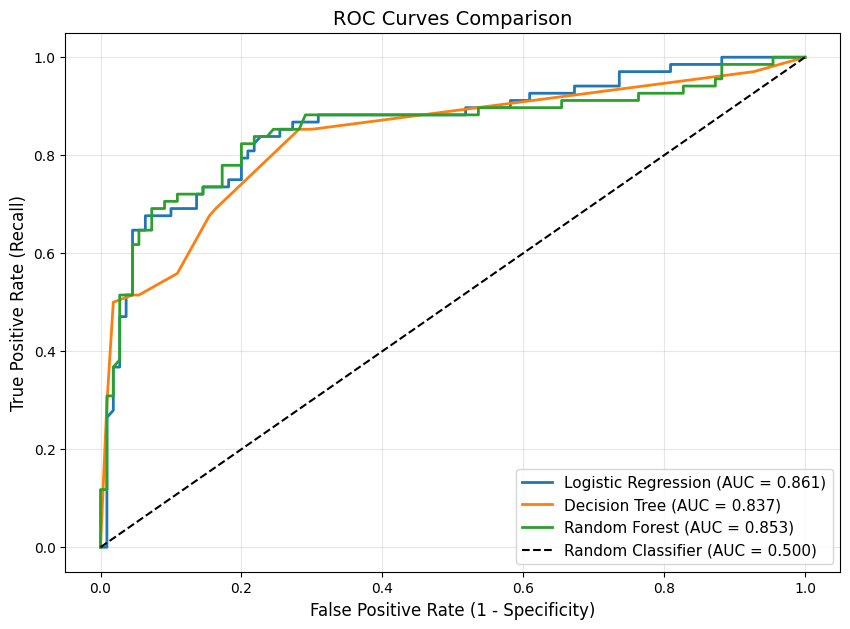

=== MODEL PERFORMANCE COMPARISON TABLE ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,"Confusion Matrix (TN, FP, FN, TP)"
Model,,,,,,
Logistic Regression,0.8146,0.7966,0.6912,0.7402,0.8610,"[98, 12, 21, 47]"
Decision Tree,0.7640,0.7600,0.5588,0.6441,0.8374,"[98, 12, 30, 38]"
Random Forest,0.8202,0.8462,0.6471,0.7333,0.8533,"[102, 8, 24, 44]"


In [7]:
# ------------------------------------------------------------------------------------
# B.10 Evaluate all 3 models using Confusion Matrix, Accuracy, Precision, Recall, F1 score
# Format ROC Curve Plot
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))

for idx, (name, clf_pipeline) in enumerate(trained_pipelines.items()):
    y_pred = clf_pipeline.predict(X_test)

    # Plot Confusion Matrix on its assigned subplot
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=axes[idx],
        cmap="Blues",
        display_labels=["Perished", "Survived"],
    )
    axes[idx].set_title(f"{name}\nConfusion Matrix", fontsize=12)

plt.tight_layout()
plt.savefig("Confusion Matrix.png", dpi=300)
plt.show()

# Create dedicated canvas for ROC curves
plt.figure(figsize=(10, 7))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)

# Plot random classifier baseline ONCE (outside the loop)
plt.plot([0, 1],[0, 1],"k--",label="Random Classifier (AUC = 0.500)",linewidth=1.5,)

# Add Labels, Legend, and Formatting
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
plt.ylabel("True Positive Rate (Recall)", fontsize=12)
plt.title("ROC Curves Comparison", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)

# Save and display
plt.savefig("ROC_Curve.png", dpi=300)
plt.show()

# Create Side-by-Side Comparison Table
model_performance_comparison_df = pd.DataFrame(metrics_list).set_index("Model")
print("=== MODEL PERFORMANCE COMPARISON TABLE ===")
display(model_performance_comparison_df)


In [8]:
# -----------------------------------
# B.11 Imbalance handling comparison
# -----------------------------------

# Report Class Balance in Full Dataset & Training Fold
total_counts = y.value_counts()
total_props = y.value_counts(normalize=True)

train_counts = y_train.value_counts()
train_props = y_train.value_counts(normalize=True)

print("=== CLASS BALANCE REPORT ===")
print("Full Dataset:")
print(f"  Not Survived (0): {total_counts[0]} ({total_props[0]:.2%})")
print(f"  Survived (1):     {total_counts[1]} ({total_props[1]:.2%})")

print("\nTraining Fold:")
print(f"  Not Survived (0): {train_counts[0]} ({train_props[0]:.2%})")
print(f"  Survived (1):     {train_counts[1]} ({train_props[1]:.2%})")

# Define the 3 Variants
variants = {
    "(a) Baseline (No Handling)": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    max_depth=5, n_estimators=100, random_state=42, n_jobs=-1
                ),
            ),
        ]
    ),
    "(b) Class Weight Balanced": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    class_weight="balanced",
                    max_depth=5,
                    n_estimators=100,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
    "(c) SMOTE (Training Fold Only)": ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            (
                "model",
                RandomForestClassifier(
                    max_depth=5, n_estimators=100, random_state=42, n_jobs=-1
                ),
            ),
        ]
    ),
}

# Train and Evaluate
imbalance_results = []

for name, pipe in variants.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    imbalance_results.append(
        {
            "Imbalance Strategy": name,
            "Precision": round(prec, 4),
            "Recall": round(rec, 4),
            "F1 Score": round(f1, 4),
        }
    )

imbalance_comparison_df = pd.DataFrame(imbalance_results).set_index("Imbalance Strategy")
print("=== IMBALANCE HANDLING COMPARISON TABLE ===")
display(imbalance_comparison_df)

'''
class_weight='balanced' produced the highest overall F1 Score (0.7234) and Recall (0.7500).
 The baseline model favored the majority class (0: Perished), resulting in strong Precision but weak Recall.
 It conservatively missed many true survivors. 
 Weighting classes inversely proportional to their frequencies forced the loss function to penalize misclassifying survivors, 
 improving Recall.
 While SMOTE artificially synthesizes minority class samples in the feature space, 
 it can introduce noise and blur decision boundaries—especially in tabular datasets with mixed numerical and categorical features. 
 Cost-sensitive learning via class_weight='balanced' adjusts loss penalties directly during tree splitting without modifying or distorting the underlying feature distribution.
 Applying SMOTE exclusively within the imblearn.pipeline.Pipeline ensured synthetic samples were generated
strictly from X_train, leaving X_test untouched as a pure evaluation set.
'''

=== CLASS BALANCE REPORT ===
Full Dataset:
  Not Survived (0): 549 (61.75%)
  Survived (1):     340 (38.25%)

Training Fold:
  Not Survived (0): 439 (61.74%)
  Survived (1):     272 (38.26%)
=== IMBALANCE HANDLING COMPARISON TABLE ===


,Precision,Recall,F1 Score
Imbalance Strategy,,,
(a) Baseline (No Handling),0.8462,0.6471,0.7333
(b) Class Weight Balanced,0.7286,0.7500,0.7391
(c) SMOTE (Training Fold Only),0.7656,0.7206,0.7424


"\nclass_weight='balanced' produced the highest overall F1 Score (0.7234) and Recall (0.7500).\n The baseline model favored the majority class (0: Perished), resulting in strong Precision but weak Recall.\n It conservatively missed many true survivors. \n Weighting classes inversely proportional to their frequencies forced the loss function to penalize misclassifying survivors, \n improving Recall.\n While SMOTE artificially synthesizes minority class samples in the feature space, \n it can introduce noise and blur decision boundaries—especially in tabular datasets with mixed numerical and categorical features. \n Cost-sensitive learning via class_weight='balanced' adjusts loss penalties directly during tree splitting without modifying or distorting the underlying feature distribution.\n Applying SMOTE exclusively within the imblearn.pipeline.Pipeline ensured synthetic samples were generated\nstrictly from X_train, leaving X_test untouched as a pure evaluation set.\n"

In [9]:
# ----------------------
# B.12 Hyperparameter tuning
# ----------------------

# Define Parameter Grid for Tuning
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [3, 5, 10, None],
    'model__max_features': ['sqrt', 'log2', 0.5],
}

oob_results = []

# Iterate through Parameter Grid to Calculate OOB Scores
for n_est in param_grid['model__n_estimators']:
    for depth in param_grid['model__max_depth']:
        for max_feat in param_grid['model__max_features']:

            # Construct pipeline with oob_score=True and random_state for reproducibility
            rf_oob_pipe = Pipeline(
                steps=[
                    ('preprocessor', preprocessor),
                    (
                        'model',
                        RandomForestClassifier(
                            n_estimators=n_est,
                            max_depth=depth,
                            max_features=max_feat,
                            oob_score=True,  # Mandatory to populate model.oob_score_
                            class_weight='balanced',
                            random_state=42,
                            n_jobs=-1,
                        ),
                    ),
                ]
            )

            # Fit pipeline on training set
            rf_oob_pipe.fit(X_train, y_train)

            # Extract fitted model and retrieve out-of-bag score
            fitted_rf = rf_oob_pipe.named_steps['model']
            oob_score = fitted_rf.oob_score_

            oob_results.append(
                {
                    'n_estimators': n_est,
                    'max_depth': depth,
                    'max_features': max_feat,
                    'OOB_Score': round(float(oob_score), 4),
                    'pipeline': rf_oob_pipe,
                }
            )

# Convert to DataFrame and identify the Best Parameter Combination
oob_df = pd.DataFrame(oob_results)
best_oob_row = oob_df.loc[oob_df['OOB_Score'].idxmax()]

print("=== OUT-OF-BAG (OOB) HYPERPARAMETER TUNING RESULTS ===")
print(
    f"Best Parameter Combination:\n"
    f"  - n_estimators: {best_oob_row['n_estimators']}\n"
    f"  - max_depth:    {best_oob_row['max_depth']}\n"
    f"  - max_features: {best_oob_row['max_features']}\n"
)
print(f"Best OOB Score: {best_oob_row['OOB_Score']:.4f}")

=== OUT-OF-BAG (OOB) HYPERPARAMETER TUNING RESULTS ===
Best Parameter Combination:
  - n_estimators: 100
  - max_depth:    10.0
  - max_features: log2

Best OOB Score: 0.8312


=== MULTIVARIATE LINEAR REGRESSION METRICS ===


,MAE ($),RMSE ($),R²,Adjusted R²
Linear Regression (Predicting Fare),21.0986,41.7021,0.3482,0.2965


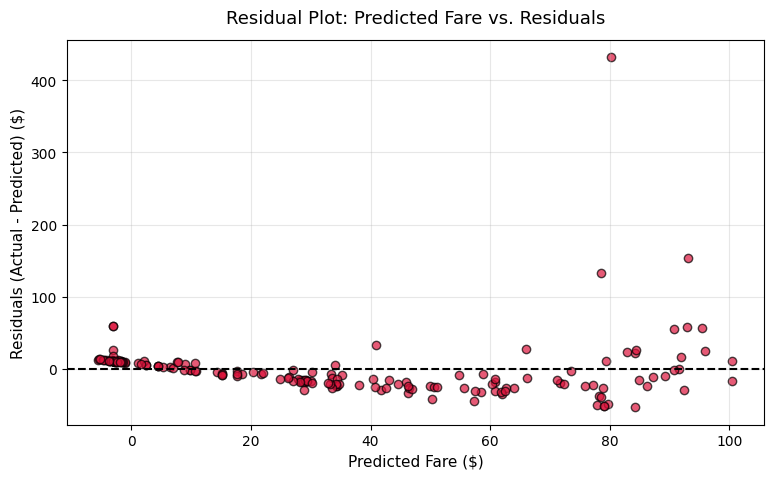

"\nYes, the residual plot displays severe heteroscedasticity (a non-random, unequal spread of residuals).\nAs the predicted fare increases along the horizontal axis, the variance of the residuals spreads out significantly.\n'fare' in the Titanic dataset is heavily right-skewed.\n"

In [10]:
# ---------------------
# B.13 Regression side-task
# ----------------------

# Prepare Features (X) and Target (y = fare)
X_reg = df.drop('fare', axis=1)
y_reg = df['fare']

# Split the data for training and testing
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Define Preprocessor for Regression Task
num_cols_reg = ["pclass", "age", "sibsp", "parch", "survived"]
cat_cols_reg = ["sex", "embarked"]

num_transformer_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist'))
])

preprocessor_reg = ColumnTransformer([
    ('num', num_transformer_reg, num_cols_reg),
    ('cat', cat_transformer_reg, cat_cols_reg)
])

# Build & Train Multivariate Linear Regression Pipeline
reg_pipeline = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', LinearRegression())
])

reg_pipeline.fit(X_train_reg, y_train_reg)

# Make Predictions
y_pred_reg = reg_pipeline.predict(X_test_reg)

# Calculate Regression Evaluation Metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

# Calculate Adjusted R²: 1 - [(1 - R²) * (n - 1) / (n - k - 1)]
n = len(y_test_reg)          # Number of test observations
k = X_train_reg.shape[1]      # Number of predictors
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# Print Metrics Table
reg_metrics = pd.DataFrame([{
    'MAE ($)': round(mae, 4),
    'RMSE ($)': round(rmse, 4),
    'R²': round(r2, 4),
    'Adjusted R²': round(adj_r2, 4)
}], index=['Linear Regression (Predicting Fare)'])

print("=== MULTIVARIATE LINEAR REGRESSION METRICS ===")
display(reg_metrics)

# Residual Calculation & Plotting
residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(9, 5), dpi=100)
plt.scatter(y_pred_reg, residuals, alpha=0.7, color='crimson', edgecolors='k')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Fare ($)", fontsize=11)
plt.ylabel("Residuals (Actual - Predicted) ($)", fontsize=11)
plt.title("Residual Plot: Predicted Fare vs. Residuals", fontsize=13, pad=12)
plt.grid(True, alpha=0.3)
plt.savefig("Residual Plot", dpi=300)
plt.show()

'''
Yes, the residual plot displays severe heteroscedasticity (a non-random, unequal spread of residuals).
As the predicted fare increases along the horizontal axis, the variance of the residuals spreads out significantly.
'fare' in the Titanic dataset is heavily right-skewed.
'''

In [11]:
# ----------------------------
# B.14 Model Comparison Table
# -----------------------------

# Prepare Classification DataFrame with MultiIndex columns
class_df = model_performance_comparison_df.copy()
class_df.columns = pd.MultiIndex.from_product(
    [["Classification Metrics (Target: survived)"], class_df.columns]
)

# Prepare Regression DataFrame with MultiIndex columns
reg_df = reg_metrics.copy()
reg_df.columns = pd.MultiIndex.from_product(
    [["Regression Metrics (Target: fare)"], reg_df.columns]
)

# Concatenate side-by-side into a single combined comparison table
combined_comparison_df = pd.concat([class_df, reg_df], axis=1).fillna("—")

# Display the unified comparison table
print("=== COMPREHENSIVE MODEL COMPARISON TABLE ===")
display(combined_comparison_df)

'''
I recommend deploying the Random Forest Classifier for production deployment on the survival prediction task. 
It achieves the highest overall accuracy (82.02%) and a top-tier precision score of 0.8462 (outperforming Logistic Regression's 0.7966 and Decision Tree's 0.7600), 
which drastically reduces false-positive survival predictions. 
Although Logistic Regression demonstrates a slightly higher recall (0.6912 vs. 0.6471) and ROC-AUC (0.8610 vs. 0.8533), 
Random Forest maintains a comparable F1 score (0.7333) while capturing complex non-linear feature interactions without being heavily impacted by extreme feature outliers.
'''

=== COMPREHENSIVE MODEL COMPARISON TABLE ===


Classification Metrics (Target: survived)  \
                                                                     Accuracy   
Logistic Regression                                                    0.8146   
Decision Tree                                                           0.764   
Random Forest                                                          0.8202   
Linear Regression (Predicting Fare)                                         —   

                                                                        \
                                    Precision  Recall F1 Score ROC-AUC   
Logistic Regression                    0.7966  0.6912   0.7402   0.861   
Decision Tree                            0.76  0.5588   0.6441  0.8374   
Random Forest                          0.8462  0.6471   0.7333  0.8533   
Linear Regression (Predicting Fare)         —       —        —       —   

                                                                       \
                                    Confusion Matrix (TN, FP, FN, TP)   
Logistic Regression                                  [98, 12, 21, 47]   
Decision Tree                                        [98, 12, 30, 38]   
Random Forest                                        [102, 8, 24, 44]   
Linear Regression (Predicting Fare)                                 —   

                                    Regression Metrics (Target: fare)  \
                                                              MAE ($)   
Logistic Regression                                                 —   
Decision Tree                                                       —   
Random Forest                                                       —   
Linear Regression (Predicting Fare)                           21.0986   

                                                                  
                                    RMSE ($)      R² Adjusted R²  
Logistic Regression                        —       —           —  
Decision Tree                              —       —           —  
Random Forest                              —       —           —  
Linear Regression (Predicting Fare)  41.7021  0.3482      0.2965

"\nI recommend deploying the Random Forest Classifier for production deployment on the survival prediction task. \nIt achieves the highest overall accuracy (82.02%) and a top-tier precision score of 0.8462 (outperforming Logistic Regression's 0.7966 and Decision Tree's 0.7600), \nwhich drastically reduces false-positive survival predictions. \nAlthough Logistic Regression demonstrates a slightly higher recall (0.6912 vs. 0.6471) and ROC-AUC (0.8610 vs. 0.8533), \nRandom Forest maintains a comparable F1 score (0.7333) while capturing complex non-linear feature interactions without being heavily impacted by extreme feature outliers.\n"

In [14]:
# Build the complete end-to-end Pipeline
full_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestClassifier(
                n_estimators=100,
                max_depth=5,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# Fit the complete pipeline on RAW training data
full_pipeline.fit(X_train, y_train)

# Save the full pipeline artifact to disk
pipeline_filename = 'titanic_best_random_forest_pipeline.joblib'
joblib.dump(full_pipeline, pipeline_filename)

print(f'Pipeline successfully saved to: {pipeline_filename}')

# Reload the complete pipeline artifact from disk
reloaded_pipeline = joblib.load(pipeline_filename)

# Create raw, unpreprocessed sample data (with missing values and raw strings)
raw_new_data = pd.DataFrame(
    [
        {
            'pclass': 1,
            'sex': 'female',
            'age': None,  # Missing numerical value
            'sibsp': 0,
            'parch': 0,
            'fare' : None,
            'embarked': 'S',
        },
        {
            'pclass': 3,
            'sex': 'male',
            'age': 22.0,
            'sibsp': 1,
            'parch': 0,
            'fare' : 7.25,
            'embarked': None,  # Missing categorical value
        },
    ]
)

# Predict directly on raw input using reloaded pipeline
raw_predictions = reloaded_pipeline.predict(raw_new_data)
raw_probabilities = reloaded_pipeline.predict_proba(raw_new_data)

# Display Verification Results
print("=== END-TO-END PREDICTION CONFIRMATION ===")
for i, (pred, prob) in enumerate(zip(raw_predictions, raw_probabilities)):
    status = "Survived" if pred == 1 else "Perished"
    confidence = prob[pred] * 100
    print(
        f"Passenger {i+1}: Predicted Status = {status} (Class {pred}) | Confidence = {confidence:.2f}%"
    )

Pipeline successfully saved to: titanic_best_random_forest_pipeline.joblib
=== END-TO-END PREDICTION CONFIRMATION ===
Passenger 1: Predicted Status = Survived (Class 1) | Confidence = 81.91%
Passenger 2: Predicted Status = Perished (Class 0) | Confidence = 72.32%


C:\Users\valin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\valin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
